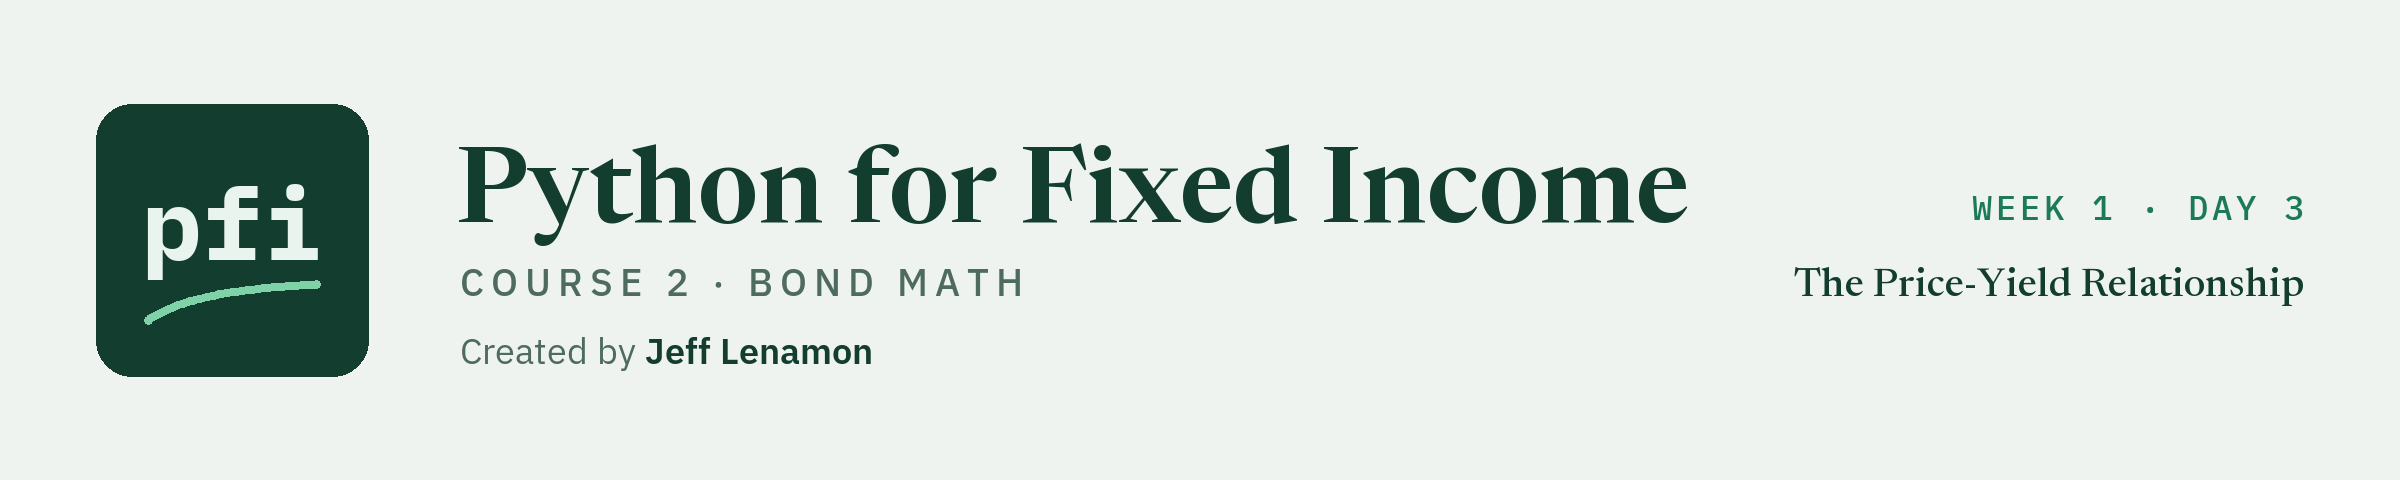

# The Price-Yield Relationship

Week 1, Day 3. Why a bond prices above, at, or below 100, how far its price moves when its yield moves, and how to restate a yield at another compounding frequency, with one more function for your module.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day3/03_the_price_yield_relationship.ipynb)

Yesterday ended with a price for each of the desk's four new bonds, every one on its coupon date of 30 September 2026. Pellwick Paper came out at 100.4159, above 100. Dunmarrow Rail came out at 100. Quorvane Energy, 99.3503, and Halvering Foods, 98.6227, came out below 100. Day 2 promised an explanation.

Today is about **the relationship between price and yield.** The price is a function of the yield, so when the yield moves the price moves the other way, and some bonds move much more than others. A desk reads every quote through that relationship.

Today you will:

1. Say why a bond prices at a premium, at par, or at a discount, from its coupon and its yield.
2. Draw the price-yield curve for the four bonds, and see that it is not a straight line.
3. Find which bond's price moves more when the yield moves, by maturity and by coupon.
4. Watch the price pull to par, coupon date by coupon date, when the yield stays where it is.
5. Restate a yield at another compounding frequency, and add `convert_yield` to your module with two tests from Excel's `EFFECT` and `NOMINAL`.
6. Write a commit message that says what changed and why, and read it back with `git log` and `git show`.

The bonds still settle on a coupon date, so `price_from_yield` from day 2 does all the pricing. Excel stays the answer key.

The issuers are invented. Every number here describes the data, and nothing says a bond or an issuer is good or bad. Every yield move today is a what-if on the four bonds, not a forecast.

The setup cell is the same as yesterday's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 2, so a new work folder starts from the right place.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_03_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_03_a8fpv4wc, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield']


* The two files exactly as day 2 left them: four functions and six tests. The import cell lists the four. By the end of today there will be five.

As yesterday, record the work folder's starting point in Git first, so the Git section can show exactly what today adds.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_03_a8fpv4wc and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 3: bondmath.py and test_bondmath.py as day 2 left them"
!git -C "{work}" log --oneline

1e18435 Start of day 3: bondmath.py and test_bondmath.py as day 2 left them


* One commit, the start of day 3. Its hash changes on every run.

Q. Type in the four bonds and price each one at its own yield.

In [8]:
bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30'],
    "years": [5, 7, 3, 10],
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
})

# day 2's function: one price for each bond, at its own coupon, yield, and years
bonds["price"] = [
    bondmath.price_from_yield(c, y, t) for c, y, t in zip(bonds["coupon_pct"], bonds["yield_pct"], bonds["years"])
]
bonds[["issuer", "coupon_pct", "yield_pct", "years", "price"]].round(4)

,issuer,coupon_pct,yield_pct,years,price
0,Quorvane Energy,5.250,5.400,5,99.3503
1,Dunmarrow Rail,6.125,6.125,7,100.0000
2,Pellwick Paper,4.750,4.600,3,100.4159
3,Halvering Foods,7.500,7.700,10,98.6227


* Yesterday's four prices, from yesterday's function. Every section today starts from them.

## 3.1 Par, Premium, and Discount

A bond's price is quoted per 100 of face. **Par** is 100. A bond that prices above 100 trades at a **premium**, and one that prices below 100 trades at a **discount**. On a coupon date one comparison decides which: the coupon against the yield.

Q. Label each bond premium, par, or discount, and put the coupon beside the yield.

In [9]:
def par_label(price):
    """premium above 100, par at 100, discount below. Rounded to 6 decimals, so the last binary digit does not count."""
    if round(price, 6) > 100:
        return "premium"
    if round(price, 6) < 100:
        return "discount"
    return "par"

# the coupon's excess over the yield, in percentage points, and the label from the price
bonds["coupon_minus_yield"] = bonds["coupon_pct"] - bonds["yield_pct"]
bonds["label"] = [par_label(p) for p in bonds["price"]]

bonds[["issuer", "coupon_pct", "yield_pct", "coupon_minus_yield", "price", "label"]].round(4)

,issuer,coupon_pct,yield_pct,coupon_minus_yield,price,label
0,Quorvane Energy,5.250,5.400,-0.15,99.3503,discount
1,Dunmarrow Rail,6.125,6.125,0.00,100.0000,par
2,Pellwick Paper,4.750,4.600,0.15,100.4159,premium
3,Halvering Foods,7.500,7.700,-0.20,98.6227,discount


* Pellwick's coupon is 0.15 points above its yield, and it prices at a premium. Dunmarrow's coupon equals its yield, and it prices at par. Quorvane's and Halvering's coupons are below their yields, and both price at a discount.
* The rule on a coupon date: **coupon above yield, premium; coupon equal to yield, par; coupon below yield, discount.**
* `par_label` rounds to six decimals because Dunmarrow's price is 100.0000000000001: 100 to the last binary digit of the arithmetic, which day 2 showed Excel shares.

Q. Does a bond whose coupon equals its yield price at 100 whatever its maturity?

In [10]:
# Dunmarrow's coupon and yield, both 6.125 percent, for terms from 1 to 30 years
for years in [1, 2, 3, 5, 7, 10, 20, 30]:
    price = bondmath.price_from_yield(6.125, 6.125, years)
    print(f"{years:>2}-year term: {price:.6f} per 100 of face")

 1-year term: 100.000000 per 100 of face
 2-year term: 100.000000 per 100 of face
 3-year term: 100.000000 per 100 of face
 5-year term: 100.000000 per 100 of face
 7-year term: 100.000000 per 100 of face
10-year term: 100.000000 per 100 of face
20-year term: 100.000000 per 100 of face
30-year term: 100.000000 per 100 of face


* 100.000000 every time. Each coupon pays exactly the yield on 100, so discounting at that yield gives back the 100 that was lent, whatever the term. That is why a new bond's coupon is usually set close to the yield the market asks: it then prices close to par.

Q. How big is each premium or discount, and where does it come from?

In [11]:
rows = []
for bond in bonds.itertuples():
    # the coupon's excess over the yield, paid every half-year: negative when the coupon is below the yield
    extra_per_period = (bond.coupon_pct - bond.yield_pct) / 2
    # the present value of that excess, period by period, at the bond's yield
    extras_pv = sum(bondmath.present_value(extra_per_period, bond.yield_pct, k / 2) for k in range(1, 2 * bond.years + 1))
    rows.append({"issuer": bond.issuer, "extra_per_period": extra_per_period,
                 "price_minus_100": bond.price - 100, "pv_of_extras": extras_pv})

extras = pd.DataFrame(rows)
# the premium or discount must equal the present value of the extras
assert (extras["price_minus_100"] - extras["pv_of_extras"]).abs().max() < 1e-9
extras.round(6)

,issuer,extra_per_period,price_minus_100,pv_of_extras
0,Quorvane Energy,-0.075,-0.649673,-0.649673
1,Dunmarrow Rail,0.000,0.000000,0.000000
2,Pellwick Paper,0.075,0.415887,0.415887
3,Halvering Foods,-0.100,-1.377264,-1.377264


* Pellwick pays 0.075 per 100 more than its yield every half-year, six times. Those six extras are worth 0.415887 today, and that is exactly its premium.
* Halvering pays 0.100 less than its yield every half-year, twenty times. Those shortfalls are worth 1.377264 today, and the price sits exactly that far below 100: its discount.
* **A premium is the present value of the coupon's excess over the yield, and a discount is the present value of its shortfall.** The longer the bond, the more periods the excess or shortfall lasts, which is part of why Halvering's discount is larger than Quorvane's.

## 3.2 The Price-Yield Curve, Charted

The price depends on the yield, so a bond has a whole curve of prices, one for each yield. Start with a table for Quorvane, then draw all four.

Q. Price Quorvane at yields from 2.40 to 8.40 percent, one percentage point apart.

In [12]:
quorvane = bonds.iloc[0]

# seven yields, 1 point (100 basis points) apart, with Quorvane's own 5.40 in the middle
yields_pct = [2.4, 3.4, 4.4, 5.4, 6.4, 7.4, 8.4]
grid = pd.DataFrame({"yield_pct": yields_pct})
grid["price"] = [bondmath.price_from_yield(quorvane["coupon_pct"], y, quorvane["years"]) for y in yields_pct]

# the move from today's price, in points per 100 of face
grid["change_from_today"] = grid["price"] - quorvane["price"]
grid.round(4)

,yield_pct,price,change_from_today
0,2.4,113.3529,14.0026
1,3.4,108.4408,9.0905
2,4.4,103.7780,4.4276
3,5.4,99.3503,0.0000
4,6.4,95.1448,-4.2055
5,7.4,91.1491,-8.2012
6,8.4,87.3516,-11.9987


* The higher the yield, the lower the price: from 113.3529 at 2.40 percent to 87.3516 at 8.40 percent.
* The steps are not equal. Down 100 basis points the price rises 4.4276; up 100 basis points it falls 4.2055. Each step to the right is smaller than the one before.

Q. Draw the price-yield curve of all four bonds, for yields from 1 to 12 percent.

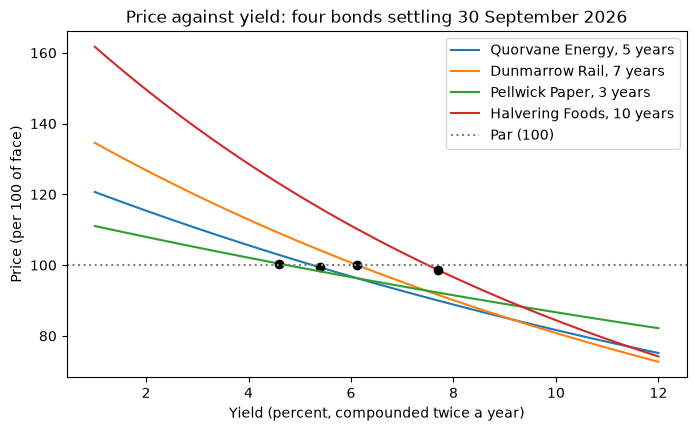

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 111 yields from 1 to 12 percent, 0.1 apart
yield_axis = np.linspace(1, 12, 111)

fig, ax = plt.subplots(figsize=(8, 4.5))
for bond in bonds.itertuples():
    # the bond's price at every yield on the axis
    curve = [bondmath.price_from_yield(bond.coupon_pct, y, bond.years) for y in yield_axis]
    ax.plot(yield_axis, curve, label=f"{bond.issuer}, {bond.years} years")
    # a black dot where the bond is today: its own yield and price
    ax.plot(bond.yield_pct, bond.price, marker="o", color="black")

# par, as a dotted line
ax.axhline(100, color="grey", linestyle=":", label="Par (100)")
ax.set_title("Price against yield: four bonds settling 30 September 2026")
ax.set_xlabel("Yield (percent, compounded twice a year)")
ax.set_ylabel("Price (per 100 of face)")
ax.legend()
plt.show()

* Every curve slopes down: **price and yield move in opposite directions.**
* Every curve bends. It is steeper on the left, at low yields, than on the right. The table above showed the same thing in numbers: 4.4276 up against 4.2055 down for the same 100 basis points. Day 10 gives that bend its name, convexity, and measures it.
* Halvering, the longest bond, has the steepest curve, and Pellwick, the shortest, the flattest. Section 3.3 measures that.
* Each curve crosses the par line where the yield equals the bond's own coupon, which is section 3.1's rule seen on a chart.

**Excel side by side.** The same curve in a sheet, tested in Excel. Type `yield_pct` in A1 and `price` in B1, the seven yields 2.4 to 8.4 in A2:A8, and in B2 `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,A2/100,100,2,0)`, filled down to B8. The yield comes from column A and is divided by 100 in the formula. Column B returns 113.352941 at 2.40 percent down to 87.351584 at 8.40 percent, the same as the table. Then select A1:B8 and choose Insert, Insert Scatter (X, Y) or Bubble Chart, Scatter with Straight Lines: Excel draws one line named `price`, with the yields along the bottom. Excel's chart is built by clicking; matplotlib's is written down, so it is drawn again the same way tomorrow.

## 3.3 Coupon and Maturity: Which Bond Moves More

On the chart some curves are steeper than others. A steeper curve means a bigger price move for the same change in yield. Measure it: move every yield by the same 100 basis points and compare.

Q. Move each bond's yield 100 basis points down and 100 up. How far does each price move, in points and in percent?

In [14]:
rows = []
for bond in bonds.itertuples():
    # 100 basis points is 1 percentage point of yield
    down = bondmath.price_from_yield(bond.coupon_pct, bond.yield_pct - 1, bond.years)
    up = bondmath.price_from_yield(bond.coupon_pct, bond.yield_pct + 1, bond.years)
    rows.append({
        "issuer": bond.issuer,
        "years": bond.years,
        "down_100bp_points": down - bond.price,
        "up_100bp_points": up - bond.price,
        # percent of today's price
        "down_100bp_pct": (down - bond.price) / bond.price * 100,
        "up_100bp_pct": (up - bond.price) / bond.price * 100,
    })

moves = pd.DataFrame(rows).sort_values("years")
moves.round(4)

,issuer,years,down_100bp_points,up_100bp_points,down_100bp_pct,up_100bp_pct
2,Pellwick Paper,3,2.8268,-2.7335,2.8151,-2.7222
0,Quorvane Energy,5,4.4276,-4.2055,4.4566,-4.2330
1,Dunmarrow Rail,7,5.8202,-5.4374,5.8202,-5.4374
3,Halvering Foods,10,7.1402,-6.5299,7.2399,-6.6211


* Sorted by years. Pellwick, 3 years, falls 2.72 percent when its yield rises 100 basis points. Halvering, 10 years, falls 6.62 percent.
* Every bond gains more when its yield falls than it loses when its yield rises: the bend from section 3.2, on every bond.
* But these bonds differ in coupon as well as maturity. To see each effect on its own, change one thing at a time.

Q. Keep Quorvane's coupon, 5.25 percent, and yield, 5.40 percent, and change only the maturity. How far does the price fall for a 100 basis point rise?

In [15]:
rows = []
for years in [1, 2, 3, 5, 7, 10, 20, 30]:
    # the same coupon and yield, at each maturity: what-ifs on Quorvane's terms, not bonds on the desk
    before = bondmath.price_from_yield(5.25, 5.40, years)
    after = bondmath.price_from_yield(5.25, 6.40, years)
    rows.append({"years": years, "price": before, "up_100bp_pct": (after - before) / before * 100})

pd.DataFrame(rows).round(4)

,years,price,up_100bp_pct
0,1,99.8559,-0.9543
1,2,99.7192,-1.8516
2,3,99.5896,-2.6950
3,5,99.3503,-4.2330
4,7,99.1352,-5.5911
5,10,98.8526,-7.3353
6,20,98.1792,-11.2557
7,30,97.7839,-13.3333


* The longer the maturity, the bigger the fall: 0.95 percent at 1 year, 4.23 at 5, 13.33 at 30.
* It grows less than in proportion. A 30-year bond does not fall 30 times as far as a 1-year bond: the far-off cash flows are discounted so heavily that they carry less and less of the price.

Q. Now keep the maturity, 5 years, and the yield, 5.40 percent, and change only the coupon.

In [16]:
rows = []
for coupon_pct in [0.0, 2.5, 5.25, 8.0, 10.5]:
    # the same maturity and yield, with each coupon: what-ifs again
    before = bondmath.price_from_yield(coupon_pct, 5.40, 5)
    after = bondmath.price_from_yield(coupon_pct, 6.40, 5)
    rows.append({"coupon_pct": coupon_pct, "price": before, "up_100bp_pct": (after - before) / before * 100})

pd.DataFrame(rows).round(4)

,coupon_pct,price,up_100bp_pct
0,0.00,76.6118,-4.7407
1,2.50,87.4397,-4.4660
2,5.25,99.3503,-4.2330
3,8.00,111.2610,-4.0499
4,10.50,122.0889,-3.9144


* The lower the coupon, the bigger the fall: 4.74 percent with no coupon at all, 3.91 with a 10.5 percent coupon.
* A low coupon puts more of the bond's value in the 100 at the end, the cash flow furthest away, and the furthest cash flow is the one a yield change hits hardest. Day 2's exercise found the same weight from the other side: a long, high-coupon bond is worth mostly its coupons.
* **Longer maturity and lower coupon both mean more price sensitivity**, because both push the weight of the cash flows later. Day 9 measures that weighted time in years: duration.

**Excel side by side.** The 100 basis point moves are `PRICE` with the yield argument moved, tested in Excel. For Halvering, `=PRICE(DATE(2026,9,30),DATE(2036,9,30),7.5/100,8.7/100,100,2,0)` returns 92.092797 and `=PRICE(DATE(2026,9,30),DATE(2036,9,30),7.5/100,6.7/100,100,2,0)` returns 105.762901, the up and down prices in the table. With today's price in B1 and the moved price in B2, `=(B2-B1)/B1*100` is the percent change.

## 3.4 Pull to Par on Coupon Dates

A bond repays 100 at maturity, whatever it cost. So a premium bond's price must come down to 100 by maturity, and a discount bond's must come up to 100, even if its yield never moves. That drift is the **pull to par**.

Q. Hold Halvering's yield at 7.70 percent. What is its price on each coupon date from today to maturity?

In [17]:
halvering = bonds.iloc[3]

rows = []
for k in range(2 * halvering["years"], 0, -1):
    # k half-years left: 10 years today, then 9.5, 9, and so on down to 0.5
    years_left = k / 2
    price = bondmath.price_from_yield(halvering["coupon_pct"], halvering["yield_pct"], years_left)
    rows.append({"years_left": years_left, "price": price})
# on the maturity date the holder is paid 100 of face: the price ends at par
rows.append({"years_left": 0.0, "price": 100.0})

path = pd.DataFrame(rows)
# every second year, then the last half-year and maturity
path[path["years_left"].isin([10, 8, 6, 4, 2, 1, 0.5, 0])].round(4)

,years_left,price
0,10.0,98.6227
4,8.0,98.8218
8,6.0,99.0533
12,4.0,99.3225
16,2.0,99.6357
18,1.0,99.8110
19,0.5,99.9037
20,0.0,100.0000


* 98.6227 today, 99.1828 with 5 years left, 99.9037 half a year before maturity, then 100. The yield never moved: the price rose because maturity came closer.
* The steps grow toward the end. A discount is the present value of the coupon shortfalls still to come, and with fewer of them left it shrinks faster.

Q. Chart the pull to par for all four bonds.

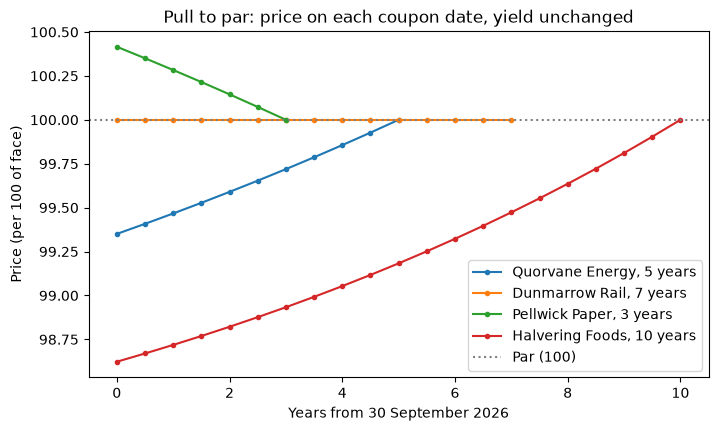

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for bond in bonds.itertuples():
    # years from today on each coupon date, from 0 to the bond's maturity
    years_from_today = [k / 2 for k in range(0, 2 * bond.years + 1)]
    # the price at the bond's own yield with the years left; at maturity, 100
    path_prices = [
        bondmath.price_from_yield(bond.coupon_pct, bond.yield_pct, bond.years - t) if t < bond.years else 100.0
        for t in years_from_today
    ]
    ax.plot(years_from_today, path_prices, marker="o", markersize=3, label=f"{bond.issuer}, {bond.years} years")

ax.axhline(100, color="grey", linestyle=":", label="Par (100)")
ax.set_title("Pull to par: price on each coupon date, yield unchanged")
ax.set_xlabel("Years from 30 September 2026")
ax.set_ylabel("Price (per 100 of face)")
ax.legend()
plt.show()

* Pellwick, the premium bond, drifts down to 100. Quorvane and Halvering, the discount bonds, drift up. Dunmarrow, at par, stays on the par line the whole way.
* Each line ends at 100 on its own maturity date: 3, 5, 7, and 10 years from today.
* In a market both things happen at once: the yield moves (sections 3.2 and 3.3) and maturity comes closer (this section). The chart isolates the second by holding the yield still. It is a what-if, not a forecast.

Q. If the yield does not move, what does each bond earn over the next half-year?

In [19]:
rows = []
for bond in bonds.itertuples():
    # the price in six months: the same yield, half a year less to run
    price_next = bondmath.price_from_yield(bond.coupon_pct, bond.yield_pct, bond.years - 0.5)
    coupon = bond.coupon_pct / 2
    pull = price_next - bond.price
    rows.append({
        "issuer": bond.issuer,
        "coupon": coupon,
        "pull_to_par": pull,
        # what the holder gets, the coupon plus the price change, as a percent of today's price
        "half_year_return_pct": (coupon + pull) / bond.price * 100,
        "half_the_yield_pct": bond.yield_pct / 2,
    })

earned = pd.DataFrame(rows)
# the half-year return must equal half the yield, for every bond
assert (earned["half_year_return_pct"] - earned["half_the_yield_pct"]).abs().max() < 1e-9
earned.round(6)

,issuer,coupon,pull_to_par,half_year_return_pct,half_the_yield_pct
0,Quorvane Energy,2.6250,0.057459,2.7000,2.7000
1,Dunmarrow Rail,3.0625,0.000000,3.0625,3.0625
2,Pellwick Paper,2.3750,-0.065435,2.3000,2.3000
3,Halvering Foods,3.7500,0.046975,3.8500,3.8500


* Every bond earns exactly half its yield over the half-year: Halvering 3.8500 percent, half of 7.70. **If the yield does not change, the bond earns its yield.**
* For a discount bond part of that return arrives as pull to par: Halvering's price rises 0.046975. For a premium bond the pull works against the coupon: Pellwick's price falls 0.065435, and its coupon of 2.375 more than makes up for it.

**Excel side by side.** Pull to par in a column, tested in Excel. Type the years left in A1:A20, from 10 down to 0.5, and in B1 `=-PV(7.7/100/2,2*A1,7.5/2,100)`, filled down to B20. It is day 2's one-formula price with the number of periods read from column A. Column B returns 98.622736 with 10 years left and 99.903707 with half a year left: the same path as the table. Excel's `PRICE`, settled on each of those coupon dates in turn, returns the same column.

## 3.5 Restating a Yield at Another Compounding Frequency, and `convert_yield`

Quorvane's yield of 5.40 percent is compounded twice a year: 2.70 percent every half-year. Every bond in this course pays twice a year, and its yield is compounded at that same frequency. But some bonds pay coupons once a year and some four times a year, and a yield worked out the course's way, at the bond's own coupon frequency, is then compounded once or four times a year. Two yields compounded at different frequencies are not comparable as they stand.

To compare them, restate one at the other's frequency: **the rate that grows 100 to the same amount in one year.**

Q. How much does 100 grow to in one year at Quorvane's 5.40 percent, compounded twice a year?

In [20]:
# two half-years at 2.70 percent each
growth = 100 * (1 + quorvane["yield_pct"] / 100 / 2) ** 2

# compounded once a year, the rate that reaches the same amount is the growth itself
annual_rate_pct = growth - 100

print(f"100 grows to {growth:.6f} in one year at 5.40 percent, compounded twice a year")
print(f"The same growth compounded once a year: {annual_rate_pct:.6f} percent")

100 grows to 105.472900 in one year at 5.40 percent, compounded twice a year
The same growth compounded once a year: 5.472900 percent


* 105.472900. The second half-year earns interest on the first half-year's interest, so the year adds more than 5.40.
* Quorvane's 5.40 percent semiannual is **5.4729 percent annual**. Same bond, same cash flows: only the way the rate is quoted changed.

Q. And restated at four times a year?

In [21]:
# the rate per quarter that grows 1 to the same amount in four steps, then times 4 for the annual rate
quarterly_rate_pct = ((growth / 100) ** (1 / 4) - 1) * 4 * 100

print(f"Quarterly: {quarterly_rate_pct:.6f} percent, compounded four times a year")

Quarterly: 5.364034 percent, compounded four times a year


* 5.364034 percent. Compounding more often needs a lower quoted rate for the same growth: 5.4729 annual, 5.40 semiannual, 5.3640 quarterly. All three describe the same bond.

**Excel side by side.** Excel has a function for each direction, tested in Excel. `EFFECT` takes a rate compounded `npery` times a year and returns the annually compounded rate: `=EFFECT(5.4/100,2)` returns 0.054728999999999806, which times 100 is 5.4729 percent. `NOMINAL` goes the other way, from an annual rate to one compounded `npery` times a year: `=NOMINAL(6.25/100,2)` returns 0.06155281280883029. Both take and return decimals, so the `/100` goes in and the `*100` comes out. To go from semiannual to quarterly, chain them through the annual rate: `=EFFECT(5.4/100,2)` in A1, then `=NOMINAL(A1,4)*100` returns 5.364033925063438, the quarterly rate above to the last digit.

The recipe is always the same: from the starting frequency to one year's growth, then from that growth to the new frequency. That is one function.

Q. Add `convert_yield` to the end of `bondmath.py`. Read the cell before you run it.

In [22]:
%%writefile -a bondmath.py


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring states the units, percent in and percent out, the convention, that both rates grow 100 to the same amount in one year, and the two Excel routes.
* It stops on any frequency other than 1, 2, or 4, checking both arguments with one loop.
* Three steps, each the cell above in general form: one year's growth at the starting frequency, the rate per period at the new frequency, and back to an annual rate in percent.

Q. Reload the module, and restate each bond's yield annually and quarterly.

In [23]:
# the file changed, so read it again
importlib.reload(bondmath)

bonds["annual_pct"] = [bondmath.convert_yield(y, 2, 1) for y in bonds["yield_pct"]]
bonds["quarterly_pct"] = [bondmath.convert_yield(y, 2, 4) for y in bonds["yield_pct"]]

# the more often a rate compounds, the lower the quoted number for the same growth
assert (bonds["annual_pct"] > bonds["yield_pct"]).all() and (bonds["yield_pct"] > bonds["quarterly_pct"]).all()
bonds[["issuer", "annual_pct", "yield_pct", "quarterly_pct"]].round(6)

,issuer,annual_pct,yield_pct,quarterly_pct
0,Quorvane Energy,5.472900,5.400,5.364034
1,Dunmarrow Rail,6.218789,6.125,6.078810
2,Pellwick Paper,4.652900,4.600,4.573850
3,Halvering Foods,7.848225,7.700,7.627281


* Quorvane's row matches the two cells above: 5.472900 annual and 5.364034 quarterly.
* The gap grows with the yield. Pellwick's annual rate is 0.0529 points above its semiannual yield; Halvering's is 0.1482 above.

Q. A desk compares a bond that pays once a year, quoted at 5.45 percent, with Quorvane at 5.40 percent semiannual. Which yields more?

In [24]:
# put both on the same footing, two ways round
quorvane_annual = bondmath.convert_yield(5.40, 2, 1)
other_semiannual = bondmath.convert_yield(5.45, 1, 2)

print(f"Both annual:     Quorvane {quorvane_annual:.4f} against 5.4500 percent")
print(f"Both semiannual: Quorvane 5.4000 against {other_semiannual:.4f} percent")

Both annual:     Quorvane 5.4729 against 5.4500 percent
Both semiannual: Quorvane 5.4000 against 5.3777 percent


* Quoted as they stand, 5.45 looks higher than 5.40. Restated on the same footing, Quorvane yields more: 5.4729 against 5.45 annually, or 5.40 against 5.3777 semiannually. The comparison flipped. The annual-pay bond is a what-if, and the numbers describe the two quotes, not a preference between bonds.

Q. Add the two tests for `convert_yield`. The first checks it against every `EFFECT` and `NOMINAL` row in Excel's reference file.

In [25]:
%%writefile -a test_bondmath.py


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]

Appending to test_bondmath.py


* `EFFECT` rows go from `frequency` times a year to once a year, so the test calls `convert_yield(rate, frequency, 1)`. `NOMINAL` rows go from once a year to `frequency` times a year: `convert_yield(rate, 1, frequency)`.
* Excel returns a decimal and `bondmath` a percent, so the expected value is Excel's times 100. The comment says so, because that factor of 100 is exactly what goes wrong in today's AI check.

Q. Add the round-trip test.

In [26]:
%%writefile -a test_bondmath.py


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)

Appending to test_bondmath.py


* Semiannual to quarterly and back must return the 6.0 it started from. A round trip checks that the two directions undo each other. It cannot check that either direction is right: the AI check shows why that matters.

Q. Run the tests.

In [27]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........                                                                 [100%]
8 passed in 0.04s



* 8 dots and `8 passed`: day 1's three, day 2's three, and today's two.

Q. How many Excel numbers did the new test check?

In [28]:
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
effect_rows = tvm[tvm["function"] == "EFFECT"]
nominal_rows = tvm[tvm["function"] == "NOMINAL"]

print(f"EFFECT rows: {len(effect_rows)}, NOMINAL rows: {len(nominal_rows)}")

# the EFFECT rows for today's four bonds
effect_rows[effect_rows["case_id"].isin(["tvm_effect_09", "tvm_effect_10", "tvm_effect_11", "tvm_effect_12"])][
    ["case_id", "rate_pct", "frequency", "excel_formula", "excel_value"]]

EFFECT rows: 16, NOMINAL rows: 6


,case_id,rate_pct,frequency,excel_formula,excel_value
80,tvm_effect_09,5.400,2,"=EFFECT(5.4/100,2)",0.054729
81,tvm_effect_10,6.125,2,"=EFFECT(6.125/100,2)",0.062188
82,tvm_effect_11,4.600,2,"=EFFECT(4.6/100,2)",0.046529
83,tvm_effect_12,7.700,2,"=EFFECT(7.7/100,2)",0.078482


* 16 `EFFECT` rows and 6 `NOMINAL` rows, at frequencies 1, 2, and 4 and rates from 0.5 to 10.25 percent. Rows 9 to 12 are today's four bonds, with the exact formula Excel was given.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Premium, par, or discount | `bondmath.price_from_yield(4.75, 4.60, 3)` | `=PRICE(DATE(2026,9,30),DATE(2029,9,30),4.75/100,4.6/100,100,2,0)` | 100.415887, a premium |
| The price-yield column | the grid in 3.2 | 2.4 to 8.4 in A2:A8, `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,A2/100,100,2,0)` in B2 filled down to B8 | 113.352941 down to 87.351584 |
| The price-yield chart | `ax.plot(...)` | select A1:B8, Insert, Insert Scatter (X, Y) or Bubble Chart, Scatter with Straight Lines | one line, yields along the bottom |
| 100 basis points up | `bondmath.price_from_yield(7.5, 8.70, 10)` | `=PRICE(DATE(2026,9,30),DATE(2036,9,30),7.5/100,8.7/100,100,2,0)` | 92.092797 |
| Pull to par | the path in 3.4 | 10 down to 0.5 in A1:A20, `=-PV(7.7/100/2,2*A1,7.5/2,100)` in B1 filled down | 98.622736 up to 99.903707 |
| Semiannual to annual | `bondmath.convert_yield(5.40, 2, 1)` | `=EFFECT(5.4/100,2)` | 0.054728999999999806 |
| Annual to semiannual | `bondmath.convert_yield(6.25, 1, 2)` | `=NOMINAL(6.25/100,2)` | 0.06155281280883029 |
| Semiannual to quarterly | `bondmath.convert_yield(5.40, 2, 4)` | `=EFFECT(5.4/100,2)` in A1, `=NOMINAL(A1,4)*100` | 5.364033925063438 |

`EFFECT(nominal_rate, npery)` and `NOMINAL(effect_rate, npery)` take the rate as a decimal and the number of compounding periods a year, and return a decimal. `bondmath` works in percent, so every formula shows the `/100`, and the results need `*100` to compare with Python.

To try it: in a blank sheet, type the price-yield column and insert the chart, then type `=EFFECT(5.4/100,2)*100` in a cell. It shows Quorvane's annual rate, 5.4729 with four decimals.

Q. Does `bondmath` agree with Excel on every `PRICE`, `EFFECT`, and `NOMINAL` row?

In [29]:
rows = []
price_rows = tvm[tvm["function"] == "PRICE"]
for row in price_rows.itertuples():
    # rate_pct is the yield; every PRICE row settles on the coupon date 30 September 2026
    python_value = bondmath.price_from_yield(row.coupon_pct, row.rate_pct, row.years, int(row.frequency))
    rows.append({"case_id": row.case_id, "excel": row.excel_value, "python": python_value})
for row in effect_rows.itertuples():
    rows.append({"case_id": row.case_id, "excel": row.excel_value * 100,
                 "python": bondmath.convert_yield(row.rate_pct, int(row.frequency), 1)})
for row in nominal_rows.itertuples():
    rows.append({"case_id": row.case_id, "excel": row.excel_value * 100,
                 "python": bondmath.convert_yield(row.rate_pct, 1, int(row.frequency))})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel"]).abs()
assert answer_key["gap"].max() < 1e-6, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e}")

# Quorvane's price-yield column
answer_key[answer_key["case_id"].isin([f"tvm_price_0{k}" for k in range(1, 8)])]

Rows compared: 37, largest gap: 5.7e-14


,case_id,excel,python,gap
0,tvm_price_01,113.352941,113.352941,1.421085e-14
1,tvm_price_02,108.440836,108.440836,1.421085e-14
2,tvm_price_03,103.777957,103.777957,2.842171e-14
3,tvm_price_04,99.350327,99.350327,1.421085e-14
4,tvm_price_05,95.144819,95.144819,5.684342e-14
5,tvm_price_06,91.149100,91.149100,1.421085e-14
6,tvm_price_07,87.351584,87.351584,2.842171e-14


* All 37 rows agree: 15 `PRICE` rows with day 2's `price_from_yield`, and 22 rate rows with today's `convert_yield`. The `PRICE` column for Quorvane is the table from section 3.2.

## Save the Day with Git

A commit is only as useful as its message. In six months, `git log` is how you will find the change that matters, so the message has two jobs: **say what changed, and say why.**

* The first line, the **subject**, says what: short, in the imperative, as if completing "This commit will ...". Add `convert_yield`, not "added stuff" or "day 3".
* A blank line, then the **body**, says why: the reason someone needed the change. The code already shows how.

`git commit` takes one `-m` for each paragraph: the first becomes the subject and the second the body.

Q. What has changed since the start of the day?

In [30]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 19 +++++++++++++++++++
 test_bondmath.py | 18 ++++++++++++++++++
 2 files changed, 37 insertions(+)


* ` M` beside both files, and 19 lines added to `bondmath.py` and 18 to `test_bondmath.py`, none removed. Today added code and changed nothing that was there. `git diff bondmath.py` would show each line, as on day 2.

Q. Commit with a subject that says what and a body that says why, then look at the history.

In [31]:
# two -m options: the subject, then the body
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add convert_yield, tested against Excel EFFECT and NOMINAL" -m "Yields on bonds that pay once or four times a year must be restated before they can be compared with a semiannual yield."
!git -C "{work}" log --oneline

9f7d2f6 Add convert_yield, tested against Excel EFFECT and NOMINAL
1e18435 Start of day 3: bondmath.py and test_bondmath.py as day 2 left them


* `git log --oneline` shows each commit's subject only, one line each. That is why the subject must say what changed on its own: it is all you see when you scan the history.

Q. Show the last commit in full: its message, and the files it changed.

In [32]:
# HEAD is the commit you are on; --stat lists the files instead of every line
!git -C "{work}" show --stat HEAD

commit 9f7d2f61dfe21fb5cbe783c3e5f4bffdd8af8580
Author: Course Student <student@example.com>
Date:   Sun Oct 4 14:18:07 2026 -0400

    Add convert_yield, tested against Excel EFFECT and NOMINAL
    
    Yields on bonds that pay once or four times a year must be restated before they can be compared with a semiannual yield.

 bondmath.py      | 19 +++++++++++++++++++
 test_bondmath.py | 18 ++++++++++++++++++
 2 files changed, 37 insertions(+)


* The commit's full hash, its author (the course name and example email set for this folder), and its date.
* The message, indented: the subject, a blank line, and the body with the reason.
* The files it changed, with a count of lines each: the same 19 and 18 that `git diff --stat` showed before the commit. Without `--stat`, `git show` prints the full diff of the commit.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the `%%writefile -a bondmath.py` cell in section 3.5, without its first line. In `test_bondmath.py`, do the same with the two `%%writefile -a test_bondmath.py` cells. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
........                                                                 [100%]
8 passed in 0.06s
```

If you added the exercise functions of days 1 and 2 with their tests, you will see 10 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it with a subject and a body.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add convert_yield, tested against Excel EFFECT and NOMINAL" -m "Yields on bonds that pay once or four times a year must be restated before they can be compared with a semiannual yield."
```

**Step 5.** Read the history, then the commit in full.

```powershell
git log --oneline
git show --stat HEAD
```

```
3c4d5e6 (HEAD -> main) Add convert_yield, tested against Excel EFFECT and NOMINAL
2b3c4d5 Add cash_flows and price_from_yield, tested against Excel PV and PRICE
1a2b3c4 Add future_value and present_value, tested against Excel FV and PV
```

Your hashes will differ. In a terminal, `git show` opens in a pager when its output is long: press `q` to return to the prompt.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Say from the coupon and the yield whether a bond prices at a premium, at par, or at a discount, and value the premium as the present value of the coupon's excess.
* Draw a price-yield curve in matplotlib and in Excel, and say why it slopes down and bends.
* Say which bond's price moves more for the same yield change: the longer one, and the one with the lower coupon.
* Show the pull to par on coupon dates, and that a bond earns its yield when its yield does not change.
* Restate a yield at another compounding frequency with `convert_yield`, and in Excel with `EFFECT` and `NOMINAL`.
* Write a commit message with a subject that says what and a body that says why, and read it with `git log --oneline` and `git show --stat HEAD`.

Tomorrow, day 4, the arrow turns around: from a quoted price back to the yield. There is no formula for that, so you will solve it three ways: with Excel's Goal Seek, by halving a bracket by hand, and with a loop in your module.

## Exercises

The exercises use the second set of four bonds from days 1 and 2, bought on 30 September 2026 like the first four. The issuers are invented, every answer describes the data, and every yield move is a what-if.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [33]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. Pull to par. Hold each bond's yield where it is, and price it today and on the coupon date when it has 1 year left. Store Calderby's price with 1 year left, unrounded, in **ex1_calderby_1y**, and a list of the tickers whose price falls toward 100 as maturity comes closer in **ex1_falling**.

In [34]:
ex1_calderby_1y = ...
ex1_falling = ...

In [35]:
check("Exercise 1 Calderby with 1 year left", ex1_calderby_1y, 99.67134685052798)
check("Exercise 1 falling toward 100", ex1_falling, ["TRNW"])

Exercise 1 Calderby with 1 year left: not attempted yet
Exercise 1 falling toward 100: not attempted yet


### Exercise 2

Q. Move Osmere's yield 100 basis points down and 100 basis points up. Store the two price changes in points, unrounded, in **ex2_down_points** (the yield 100 basis points lower) and **ex2_up_points** (100 higher), and in **ex2_larger** the word `"down"` or `"up"`: the move whose price change is larger in size.

In [36]:
ex2_down_points = ...
ex2_up_points = ...
ex2_larger = ...

In [37]:
check("Exercise 2 yield down 100 bp", ex2_down_points, 5.176570543702951)
check("Exercise 2 yield up 100 bp", ex2_up_points, -4.873065902034114)
check("Exercise 2 larger move", ex2_larger, "down")

Exercise 2 yield down 100 bp: not attempted yet
Exercise 2 yield up 100 bp: not attempted yet
Exercise 2 larger move: not attempted yet


### Exercise 3

Q. With `bondmath.convert_yield`, restate Calderby's semiannual yield as an annual rate, and Osmere's as a quarterly rate. Store them, in percent and unrounded, in **ex3_calderby_annual** and **ex3_osmere_quarterly**.

In [38]:
ex3_calderby_annual = ...
ex3_osmere_quarterly = ...

In [39]:
check("Exercise 3 Calderby annual", ex3_calderby_annual, 8.784899999999984)
check("Exercise 3 Osmere quarterly", ex3_osmere_quarterly, 5.314692553822908)

Exercise 3 Calderby annual: not attempted yet
Exercise 3 Osmere quarterly: not attempted yet


### Exercise 4

Q. Add a function to your module. `price_change(old_price, new_price)` returns the change as a tuple of two numbers: points per 100 of face, and percent of the old price, both negative for a fall. Write the docstring first: units, convention, and the Excel formulas. Then add a test to `test_bondmath.py`, called `test_price_change_points_and_percent`, with two cases you can check by hand, and a check that every step up the yield column of Excel's `PRICE` rows for the 5.25 percent coupon (`tvm_rows("PRICE")`) gives a fall in price. Run pytest, and store the percent change of Halvering's price when its yield moves from 7.70 to 8.70 percent, from `bondmath.price_change`, in **ex4_percent**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [40]:
%%writefile -a bondmath.py


# Exercise 4: write price_change(old_price, new_price) below this line

Appending to bondmath.py


In [41]:
%%writefile -a test_bondmath.py


# Exercise 4: write test_price_change_points_and_percent() below this line

Appending to test_bondmath.py


In [42]:
# run pytest, reload the module, then call your function
ex4_percent = ...

In [43]:
check("Exercise 4 percent change", ex4_percent, -6.621129485219808)

Exercise 4 percent change: not attempted yet


### Exercise 5: AI check

You ask an AI assistant to write `convert_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The same yield restated at another compounding frequency.

Units: yield_pct in percent a year; the result is in percent a year.
Convention: both rates grow 100 to the same amount in one year.
Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [44]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_convert_yield(yield_pct, from_frequency, to_frequency):
    """The same yield restated at another compounding frequency.

Units: yield_pct in percent a year; the result is in percent a year.
Convention: both rates grow 100 to the same amount in one year.
Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # the annual rate
    return period_rate * to_frequency

Q. Before you run the next cell: what should the function return for Quorvane's 5.40 percent semiannual, restated annually? Section 3.5 has the number.

In [45]:
print(f"Quorvane annual from the assistant's function: {assistant_convert_yield(5.40, 2, 1):.4f}")

Quorvane annual from the assistant's function: 12.6900


Q. A semiannual yield of 5.40 should restate to a little above 5.40 annually, not more than double it. Test the function against every `EFFECT` and `NOMINAL` row of Excel's reference file before you trust it.

In [46]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
effect_rows = tvm[tvm["function"] == "EFFECT"]
nominal_rows = tvm[tvm["function"] == "NOMINAL"]

# EFFECT: from `frequency` times a year to once a year. Excel returns a decimal, so times 100.
for row in effect_rows.itertuples():
    result = assistant_convert_yield(row.rate_pct, int(row.frequency), 1)
    assert abs(result - row.excel_value * 100) < 1e-9, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

# NOMINAL: from once a year to `frequency` times a year
for row in nominal_rows.itertuples():
    result = assistant_convert_yield(row.rate_pct, 1, int(row.frequency))
    assert abs(result - row.excel_value * 100) < 1e-9, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

print(f"All {len(effect_rows) + len(nominal_rows)} EFFECT and NOMINAL rows match Excel")

AssertionError: tvm_effect_01: 11.250000 against Excel's 5.062500

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store `assistant_convert_yield(5.40, 2, 1)` in **ex5_quorvane** and the number of rows the test checked in **ex5_rows**.

In [47]:
# fix the function above and run the test again, then store the two answers
ex5_quorvane = ...
ex5_rows = ...

In [48]:
check("Exercise 5 Quorvane annual", ex5_quorvane, 5.472899999999981)
check("Exercise 5 rows checked", ex5_rows, 22)

Exercise 5 Quorvane annual: not attempted yet
Exercise 5 rows checked: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```